
MODELAGEM PREDITIVA DA EVASÃO ESCOLAR: UMA ABORDAGEM COMPARATIVA

Autor: [Seu Nome]
Orientador: [Nome do Orientador]
Instituição: [Sua Instituição]
Curso: [Seu Curso]
Data: 2026-05-10

Resumo
------
Este notebook apresenta uma análise comparativa abrangente de modelos de
classificação para previsão de evasão escolar. A metodologia inclui:
- Balanceamento da base de dados (undersampling da classe majoritária)
- Ajuste de hiperparâmetros via RandomizedSearchCV
- Comparação de 9 algoritmos de aprendizado supervisionado
- Validação cruzada estratificada com 5 folds
- Análise de interpretabilidade com SHAP e importância por permutação
- Métricas completas: acurácia, precisão, recall, F1, AUC-ROC,
  matriz de confusão e curvas ROC

Palavras-chave: evasão escolar, classificação, machine learning, SHAP


In [2]:
# =============================================================================
# 1. CONFIGURAÇÃO DO AMBIENTE E IMPORTAÇÃO DE BIBLIOTECAS
# =============================================================================

# 1.1 Instalação de pacotes adicionais (execute se necessário)
# !pip install xgboost lightgbm catboost shap imbalanced-learn -q

# 1.2 Importações principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from datetime import datetime

warnings.filterwarnings('ignore')

# Pré-processamento e avaliação
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    make_scorer, balanced_accuracy_score, matthews_corrcoef,
    average_precision_score, cohen_kappa_score
)

# Balanceamento
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Modelos lineares e clássicos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Ensembles
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier,
    VotingClassifier, StackingClassifier
)

# Gradient Boosting avançado
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

# Rede neural
from sklearn.neural_network import MLPClassifier

# Interpretabilidade
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Configuração de sementes para reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Configuração de cores consistentes
COLORS = sns.color_palette("husl", 10)

print("=" * 70)
print("AMBIENTE CONFIGURADO COM SUCESSO")
print(f"Data de execução: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 70)


AMBIENTE CONFIGURADO COM SUCESSO
Data de execução: 2026-05-10 10:26:15



2. CARREGAMENTO E ANÁLISE EXPLORATÓRIA DOS DADOS

Dimensões originais: (178772, 16)
Número de features: 15

Dimensões após remoção das features de criação do target: (178772, 11)

--------------------------------------------------
DISTRIBUIÇÃO DO TARGET
--------------------------------------------------
Classe 0 (Não Evasão): 130,107 (72.78%)
Classe 1 (Evasão):     48,665 (27.22%)
Razão de desbalanceamento: 2.67:1


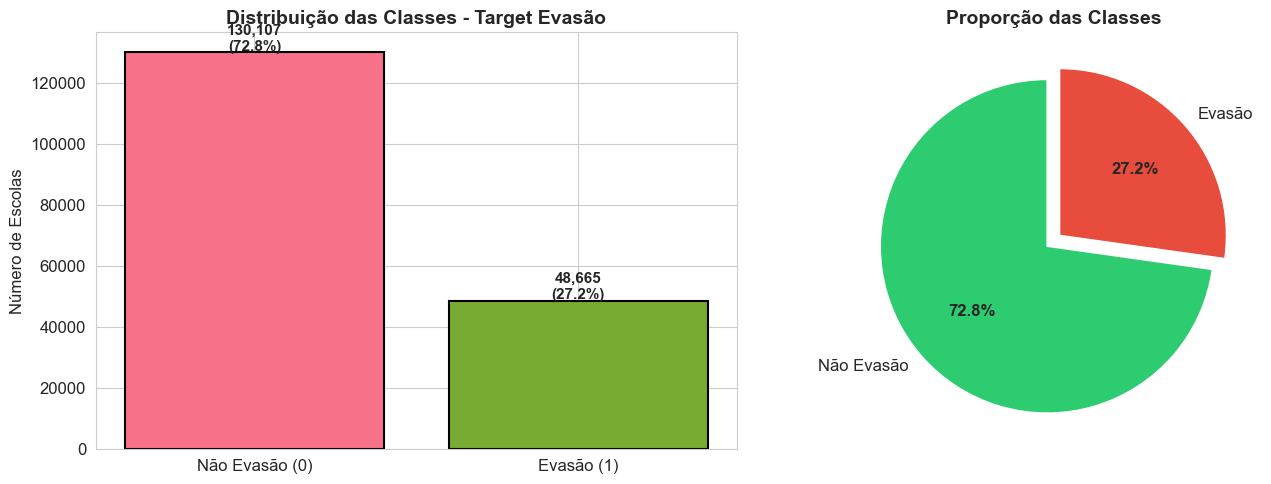


--------------------------------------------------
ESTATÍSTICAS DESCRITIVAS DAS FEATURES
--------------------------------------------------
       CO_ENTIDADE  CO_MUNICIPIO      CO_UF  QT_DOC_BAS_FEM  QT_DOC_BAS_MASC  \
count    178772.00     178772.00  178772.00       178772.00        178772.00   
mean   30782019.17    3076652.21      30.62           12.68             4.06   
std     9742409.78     977914.97       9.74           10.62             6.67   
min    11000023.00    1100015.00      11.00            0.00             0.00   
25%    23545540.00    2314003.00      23.00            5.00             0.00   
50%    31249401.00    3136207.00      31.00           10.00             1.00   
75%    35301258.00    3550308.00      35.00           17.00             5.00   
max    53086007.00    5300108.00      53.00          215.00           212.00   

       QT_GESTORES  QT_TUR_MED  QT_TUR_PROF  tem_ensino_medio  \
count     178772.0   178772.00    178772.00         178772.00   
mean    

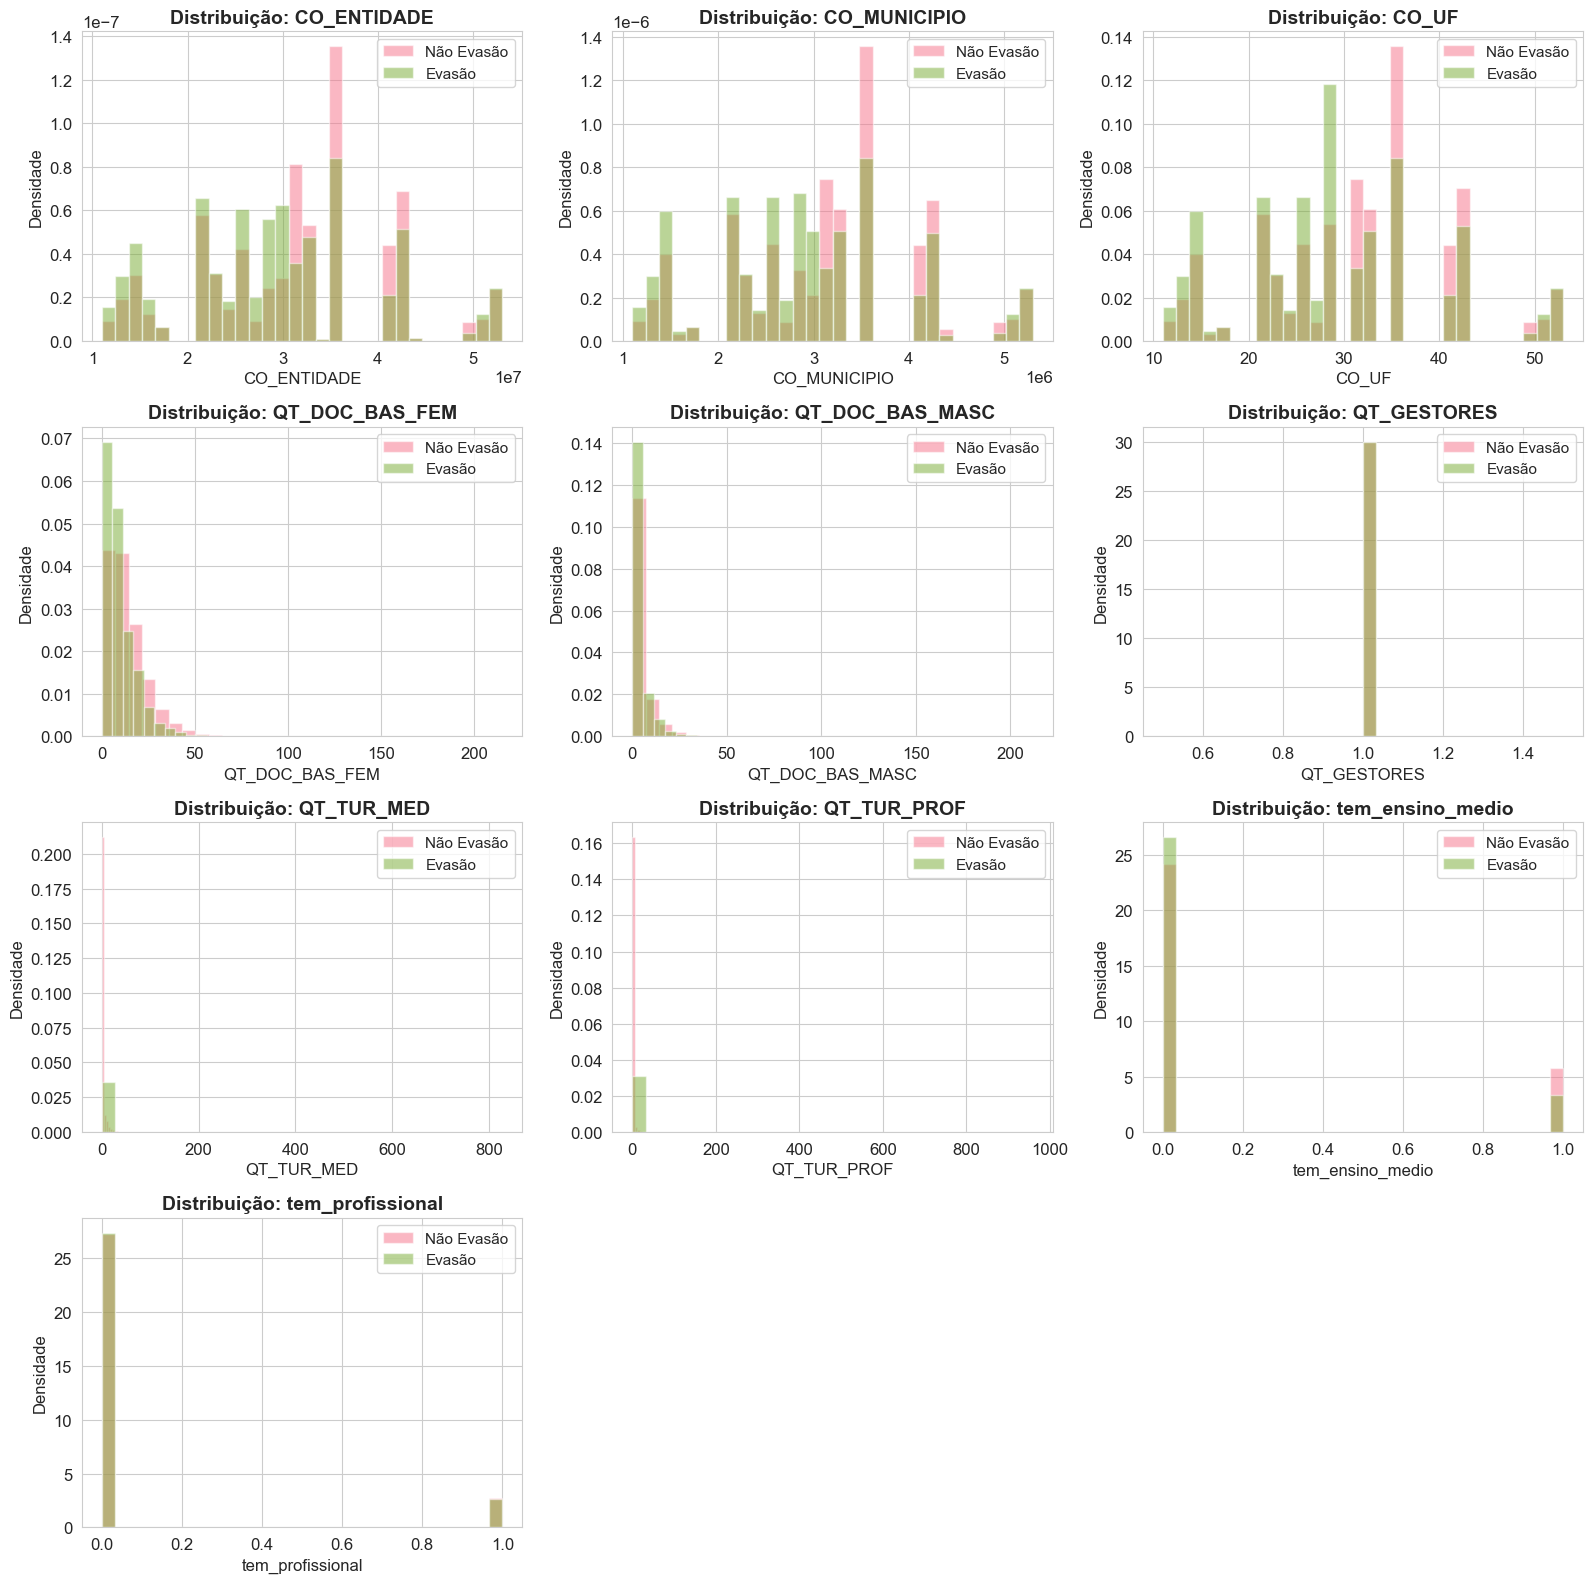

In [7]:
# =============================================================================
# 2. CARREGAMENTO E ANÁLISE EXPLORATÓRIA DOS DADOS
# =============================================================================

print("\n" + "=" * 70)
print("2. CARREGAMENTO E ANÁLISE EXPLORATÓRIA DOS DADOS")
print("=" * 70)

# 2.1 Leitura do dataset
df = pd.read_parquet("data/gold/gold_escolas_evasao.parquet")
print(f"\nDimensões originais: {df.shape}")
print(f"Número de features: {df.shape[1] - 1}")

# 2.2 Remoção das features usadas para criação do target
cols_regra = ['QT_TUR_EJA', 'prop_turmas_eja', 'QT_DOC_BAS', 'QT_TUR_BAS', 
              'docentes_por_turma']
df_clean = df.drop(columns=[c for c in cols_regra if c in df.columns], errors='ignore')
print(f"\nDimensões após remoção das features de criação do target: {df_clean.shape}")

# 2.3 Análise da distribuição do target
print("\n" + "-" * 50)
print("DISTRIBUIÇÃO DO TARGET")
print("-" * 50)

target_dist = df_clean['target_evasao'].value_counts()
target_dist_pct = df_clean['target_evasao'].value_counts(normalize=True)

print(f"Classe 0 (Não Evasão): {target_dist[0]:,} ({target_dist_pct[0]:.2%})")
print(f"Classe 1 (Evasão):     {target_dist[1]:,} ({target_dist_pct[1]:.2%})")
print(f"Razão de desbalanceamento: {target_dist[0]/target_dist[1]:.2f}:1")

# Visualização da distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
ax1 = axes[0]
bars = ax1.bar(['Não Evasão (0)', 'Evasão (1)'], target_dist.values, 
               color=[COLORS[0], COLORS[3]], edgecolor='black', linewidth=1.5)
ax1.set_title('Distribuição das Classes - Target Evasão', fontweight='bold')
ax1.set_ylabel('Número de Escolas')
for bar, value in zip(bars, target_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{value:,}\n({value/len(df_clean)*100:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')

# Gráfico de pizza
ax2 = axes[1]
colors_pie = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax2.pie(
    target_dist.values, 
    labels=['Não Evasão', 'Evasão'],
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05),
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax2.set_title('Proporção das Classes', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/distribuicao_target.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.4 Estatísticas descritivas das features
print("\n" + "-" * 50)
print("ESTATÍSTICAS DESCRITIVAS DAS FEATURES")
print("-" * 50)
print(df_clean.describe().round(2))

# Visualização das distribuições das features
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [c for c in numeric_cols if c != 'target_evasao']

n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for target_val, label, color in [(0, 'Não Evasão', COLORS[0]), 
                                      (1, 'Evasão', COLORS[3])]:
        subset = df_clean[df_clean['target_evasao'] == target_val][col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color, 
                    density=True)
    axes[i].set_title(f'Distribuição: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidade')
    axes[i].legend()

# Remove eixos vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('figures/distribuicao_features.png', dpi=300, bbox_inches='tight')
plt.show()



3. PREPARAÇÃO DOS DADOS E BALANCEAMENTO

Features selecionadas (8): ['CO_UF', 'QT_DOC_BAS_FEM', 'QT_DOC_BAS_MASC', 'QT_GESTORES', 'QT_TUR_MED', 'QT_TUR_PROF', 'tem_ensino_medio', 'tem_profissional']
Total de amostras: 178,772

Divisão Treino-Teste (estratificada):
  Treino: 143,017 amostras | Evasão: 27.22%
  Teste:  35,755 amostras | Evasão: 27.22%

--------------------------------------------------
IMPUTAÇÃO DE VALORES AUSENTES
--------------------------------------------------
Nenhum valor ausente encontrado no treino.
Nenhum valor ausente encontrado no teste.

Normalização (StandardScaler) concluída para modelos sensíveis à escala.

--------------------------------------------------
BALANCEAMENTO POR UNDERSAMPLING
--------------------------------------------------

Antes do balanceamento (treino):
  Classe 0 (Não Evasão): 104,085
  Classe 1 (Evasão):     38,932

Após o balanceamento (treino):
  Classe 0 (Não Evasão): 38,932
  Classe 1 (Evasão):     38,932
  Total balanceado: 77,86

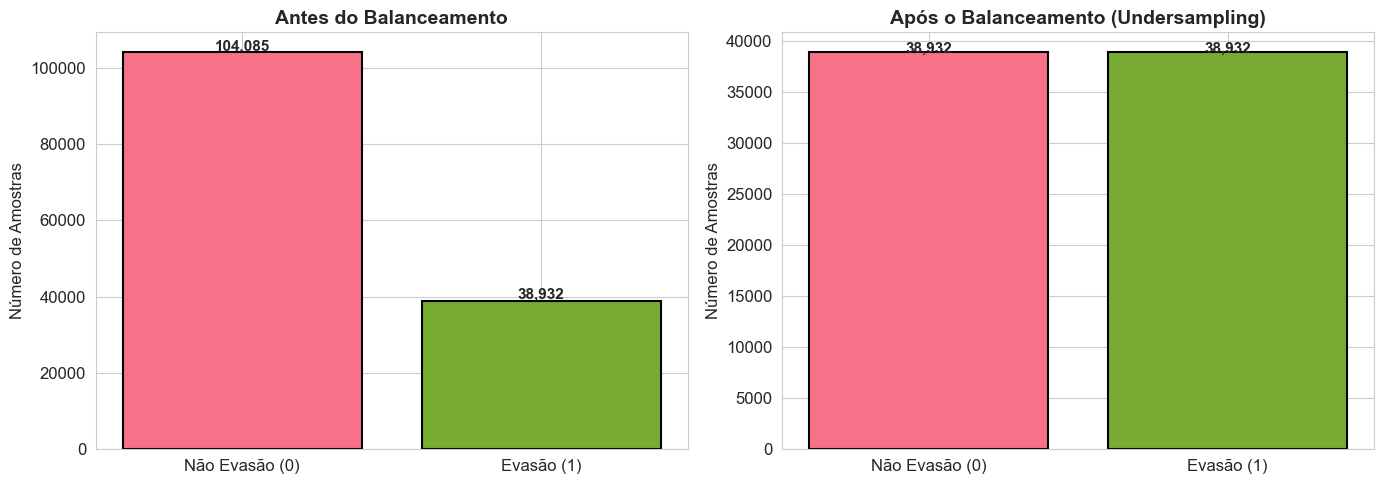

In [8]:
# =============================================================================
# 3. PREPARAÇÃO DOS DADOS E BALANCEAMENTO
# =============================================================================

print("\n" + "=" * 70)
print("3. PREPARAÇÃO DOS DADOS E BALANCEAMENTO")
print("=" * 70)

# 3.1 Separação de features e target
target_col = 'target_evasao'
id_col = 'CO_ENTIDADE' if 'CO_ENTIDADE' in df_clean.columns else None

exclude_cols = [target_col]
if id_col:
    exclude_cols.append(id_col)
if 'CO_MUNICIPIO' in df_clean.columns:
    exclude_cols.append('CO_MUNICIPIO')

features = [c for c in df_clean.columns if c not in exclude_cols]

X = df_clean[features]
y = df_clean[target_col]

print(f"\nFeatures selecionadas ({len(features)}): {features}")
print(f"Total de amostras: {len(X):,}")

# 3.2 Divisão treino-teste estratificada (antes do balanceamento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\nDivisão Treino-Teste (estratificada):")
print(f"  Treino: {X_train.shape[0]:,} amostras | Evasão: {y_train.mean():.2%}")
print(f"  Teste:  {X_test.shape[0]:,} amostras | Evasão: {y_test.mean():.2%}")

# 3.3 Imputação de valores ausentes
print("\n" + "-" * 50)
print("IMPUTAÇÃO DE VALORES AUSENTES")
print("-" * 50)

num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Verificar valores ausentes
missing_train = X_train[num_features].isnull().sum()
missing_test = X_test[num_features].isnull().sum()

if missing_train.sum() > 0:
    print(f"Valores ausentes no treino: {missing_train.sum()}")
    print(missing_train[missing_train > 0])
else:
    print("Nenhum valor ausente encontrado no treino.")

if missing_test.sum() > 0:
    print(f"\nValores ausentes no teste: {missing_test.sum()}")
    print(missing_test[missing_test > 0])
else:
    print("Nenhum valor ausente encontrado no teste.")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

X_train_proc = pd.DataFrame(X_train_proc, columns=num_features, index=X_train.index)
X_test_proc = pd.DataFrame(X_test_proc, columns=num_features, index=X_test.index)

# 3.4 Normalização para modelos sensíveis à escala
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_proc)
X_test_scaled = scaler.transform(X_test_proc)

print("\nNormalização (StandardScaler) concluída para modelos sensíveis à escala.")

# 3.5 Balanceamento da base de treino (UNDERSAMPLING)
print("\n" + "-" * 50)
print("BALANCEAMENTO POR UNDERSAMPLING")
print("-" * 50)

# Contagem antes do balanceamento
print(f"\nAntes do balanceamento (treino):")
print(f"  Classe 0 (Não Evasão): {(y_train == 0).sum():,}")
print(f"  Classe 1 (Evasão):     {(y_train == 1).sum():,}")

# Aplicar undersampling
undersampler = RandomUnderSampler(random_state=SEED)
X_train_balanced, y_train_balanced = undersampler.fit_resample(X_train_proc, y_train)

print(f"\nApós o balanceamento (treino):")
print(f"  Classe 0 (Não Evasão): {(y_train_balanced == 0).sum():,}")
print(f"  Classe 1 (Evasão):     {(y_train_balanced == 1).sum():,}")
print(f"  Total balanceado: {len(y_train_balanced):,}")

# Também balancear a versão normalizada
X_train_scaled_balanced = scaler.fit_transform(X_train_balanced)

# Visualização do balanceamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
ax1 = axes[0]
bars1 = ax1.bar(['Não Evasão (0)', 'Evasão (1)'], 
                [(y_train == 0).sum(), (y_train == 1).sum()],
                color=[COLORS[0], COLORS[3]], edgecolor='black', linewidth=1.5)
ax1.set_title('Antes do Balanceamento', fontweight='bold')
ax1.set_ylabel('Número de Amostras')
for bar, value in zip(bars1, [(y_train == 0).sum(), (y_train == 1).sum()]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{value:,}', ha='center', fontsize=11, fontweight='bold')

# Depois
ax2 = axes[1]
bars2 = ax2.bar(['Não Evasão (0)', 'Evasão (1)'], 
                [(y_train_balanced == 0).sum(), (y_train_balanced == 1).sum()],
                color=[COLORS[0], COLORS[3]], edgecolor='black', linewidth=1.5)
ax2.set_title('Após o Balanceamento (Undersampling)', fontweight='bold')
ax2.set_ylabel('Número de Amostras')
for bar, value in zip(bars2, [(y_train_balanced == 0).sum(), (y_train_balanced == 1).sum()]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/balanceamento.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# =============================================================================
# 4. DEFINIÇÃO DOS MODELOS E AJUSTE DE HIPERPARÂMETROS
# =============================================================================

print("\n" + "=" * 70)
print("4. DEFINIÇÃO DOS MODELOS E AJUSTE DE HIPERPARÂMETROS")
print("=" * 70)

# 4.1 Definição dos espaços de busca para cada modelo
param_distributions = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, class_weight='balanced', 
                                     random_state=SEED),
        'params': {
            'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        },
        'scaled': True
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 10, 15, 20],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=SEED),
        'params': {
            'max_depth': [3, 5, 8, 10, 15, None],
            'min_samples_leaf': [10, 20, 50, 100],
            'criterion': ['gini', 'entropy'],
            'class_weight': ['balanced', None]
        },
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=SEED),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 8, 10, 15, None],
            'min_samples_leaf': [10, 20, 50],
            'class_weight': ['balanced', 'balanced_subsample'],
            'bootstrap': [True, False]
        },
        'scaled': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=SEED),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 8],
            'min_samples_leaf': [10, 20],
            'subsample': [0.8, 1.0]
        },
        'scaled': False
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=SEED, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 8],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'gamma': [0, 0.1, 0.2]
        },
        'scaled': False
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=SEED, verbose=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 8, -1],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [31, 50, 100],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        },
        'scaled': False
    },
    'MLP': {
        'model': MLPClassifier(max_iter=500, random_state=SEED),
        'params': {
            'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate': ['constant', 'adaptive']
        },
        'scaled': True
    },
    'SVC': {
        'model': SVC(probability=True, random_state=SEED),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'gamma': ['scale', 'auto', 0.1, 0.01],
            'kernel': ['rbf', 'linear']
        },
        'scaled': True
    }
}

if CATBOOST_AVAILABLE:
    param_distributions['CatBoost'] = {
        'model': CatBoostClassifier(random_state=SEED, verbose=0),
        'params': {
            'iterations': [100, 200],
            'depth': [3, 5, 8],
            'learning_rate': [0.01, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5]
        },
        'scaled': False
    }

# 4.2 Função para ajuste de hiperparâmetros
def tune_model(model, param_dist, X, y, n_iter=30, cv=3):
    """Ajusta hiperparâmetros usando RandomizedSearchCV"""
    scorer = make_scorer(f1_score)
    
    random_search = RandomizedSearchCV(
        model, param_dist, n_iter=n_iter, cv=cv,
        scoring=scorer, n_jobs=-1, random_state=SEED,
        verbose=0
    )
    
    start_time = time.time()
    random_search.fit(X, y)
    elapsed_time = time.time() - start_time
    
    return random_search.best_estimator_, random_search.best_params_, elapsed_time

# 4.3 Ajuste de todos os modelos
print("\n" + "-" * 50)
print("INICIANDO AJUSTE DE HIPERPARÂMETROS")
print("-" * 50)

best_models = {}
best_params_dict = {}
tuning_times = {}

for name, config in param_distributions.items():
    print(f"\n{'>'*40}")
    print(f"Ajustando: {name}")
    print(f"{'>'*40}")
    
    X_used = X_train_scaled_balanced if config['scaled'] else X_train_balanced.values
    
    best_model, best_params, elapsed = tune_model(
        config['model'], config['params'], X_used, y_train_balanced
    )
    
    best_models[name] = best_model
    best_params_dict[name] = best_params
    tuning_times[name] = elapsed
    
    print(f"Melhores parâmetros: {best_params}")
    print(f"Tempo de ajuste: {elapsed:.2f} segundos")

# Exibir tabela de tempos de ajuste
print("\n" + "-" * 50)
print("RESUMO DOS TEMPOS DE AJUSTE")
print("-" * 50)

tuning_df = pd.DataFrame.from_dict(tuning_times, orient='index', columns=['Tempo (s)'])
tuning_df = tuning_df.sort_values('Tempo (s)', ascending=False)
print(tuning_df.round(2))



4. DEFINIÇÃO DOS MODELOS E AJUSTE DE HIPERPARÂMETROS

--------------------------------------------------
INICIANDO AJUSTE DE HIPERPARÂMETROS
--------------------------------------------------

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Ajustando: Logistic Regression
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Melhores parâmetros: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.001}
Tempo de ajuste: 12.28 segundos

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Ajustando: KNN
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Melhores parâmetros: {'weights': 'distance', 'n_neighbors': 20, 'metric': 'manhattan'}
Tempo de ajuste: 39.48 segundos

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Ajustando: Decision Tree
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Melhores parâmetros: {'min_samples_leaf': 10, 'max_depth': 3, 'criterion': 'gini', 'class_weight': 'balanced'}
Tempo de ajuste: 2.02 segundos

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Ajustando: Random Forest
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Melhores par


5. VALIDAÇÃO CRUZADA ESTRATIFICADA

Avaliando: Logistic Regression

Avaliando: KNN

Avaliando: Decision Tree

Avaliando: Random Forest

Avaliando: Gradient Boosting

Avaliando: XGBoost

Avaliando: LightGBM

Avaliando: MLP

Avaliando: SVC

Avaliando: CatBoost

RESULTADOS DA VALIDAÇÃO CRUZADA
                     accuracy  precision  recall      f1  roc_auc  \
Logistic Regression    0.6111     0.5951  0.6954  0.6413   0.6111   
KNN                    0.5718     0.6417  0.3255  0.4318   0.5718   
Decision Tree          0.6368     0.6068  0.7775  0.6815   0.6368   
Random Forest          0.6565     0.6253  0.7809  0.6945   0.6565   
Gradient Boosting      0.6415     0.6080  0.7963  0.6895   0.6415   
XGBoost                0.6415     0.6081  0.7962  0.6896   0.6415   
LightGBM               0.6416     0.6080  0.7969  0.6898   0.6416   
MLP                    0.6584     0.6409  0.7205  0.6783   0.6584   
SVC                    0.6370     0.6086  0.7680  0.6791   0.6370   
CatBoost         

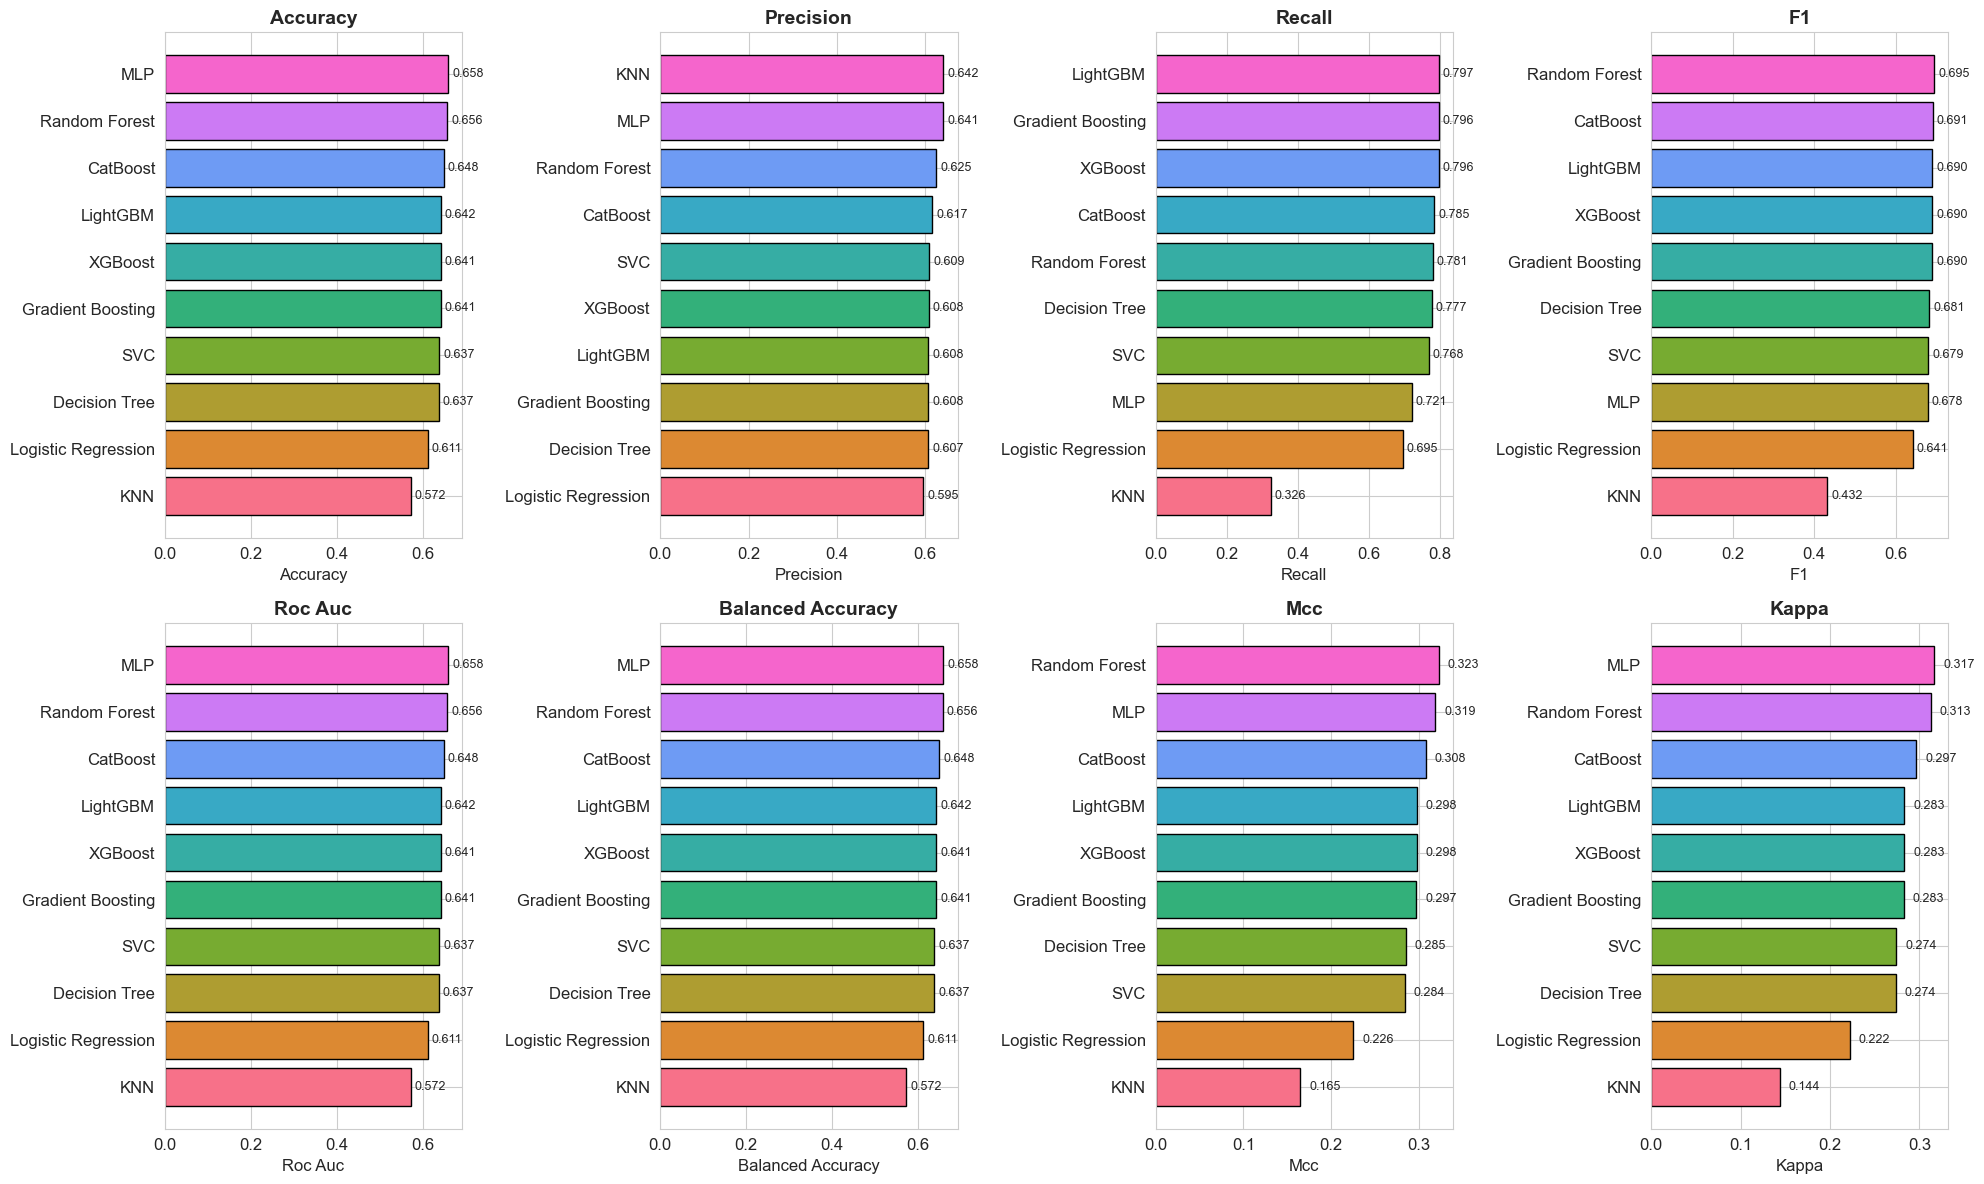

In [10]:
# =============================================================================
# 5. VALIDAÇÃO CRUZADA COMPLETA
# =============================================================================

print("\n" + "=" * 70)
print("5. VALIDAÇÃO CRUZADA ESTRATIFICADA")
print("=" * 70)

def evaluate_cv_complete(model, X, y, cv_splits=5):
    """Avaliação completa com validação cruzada"""
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, zero_division=0),
        'recall': make_scorer(recall_score, zero_division=0),
        'f1': make_scorer(f1_score, zero_division=0),
        'roc_auc': make_scorer(roc_auc_score),
        'balanced_accuracy': make_scorer(balanced_accuracy_score),
        'mcc': make_scorer(matthews_corrcoef),
        'kappa': make_scorer(cohen_kappa_score)
    }
    
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=SEED)
    
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, 
                           n_jobs=-1, return_train_score=True)
    
    results = {}
    for metric in scoring.keys():
        results[metric] = {
            'mean': scores[f'test_{metric}'].mean(),
            'std': scores[f'test_{metric}'].std()
        }
    
    return results

cv_results = {}
cv_detailed = {}

for name, config in param_distributions.items():
    print(f"\nAvaliando: {name}")
    
    X_used = X_train_scaled_balanced if config['scaled'] else X_train_balanced.values
    
    cv_results[name] = evaluate_cv_complete(best_models[name], X_used, y_train_balanced)
    
    # Extrair médias para tabela
    cv_detailed[name] = {k: v['mean'] for k, v in cv_results[name].items()}

# Criar DataFrame com resultados
cv_df = pd.DataFrame(cv_detailed).T
cv_df = cv_df.round(4)

print("\n" + "=" * 70)
print("RESULTADOS DA VALIDAÇÃO CRUZADA")
print("=" * 70)
print(cv_df)

# Visualização dos resultados da validação cruzada
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 
                   'balanced_accuracy', 'mcc', 'kappa']

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    values = cv_df[metric].sort_values(ascending=True)
    colors = [COLORS[j % len(COLORS)] for j in range(len(values))]
    bars = ax.barh(values.index, values.values, color=colors, edgecolor='black')
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel(metric.replace('_', ' ').title())
    
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/validacao_cruzada.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# =============================================================================
# 6. AVALIAÇÃO NO CONJUNTO DE TESTE
# =============================================================================

print("\n" + "=" * 70)
print("6. AVALIAÇÃO NO CONJUNTO DE TESTE")
print("=" * 70)

test_results = {}
predictions = {}
probabilities = {}

for name, config in param_distributions.items():
    print(f"\nTreinando e avaliando: {name}")
    
    X_used = X_train_scaled_balanced if config['scaled'] else X_train_balanced.values
    X_test_used = X_test_scaled if config['scaled'] else X_test_proc.values
    
    model = best_models[name]
    model.fit(X_used, y_train_balanced)
    
    y_pred = model.predict(X_test_used)
    y_proba = model.predict_proba(X_test_used)[:, 1] if hasattr(model, "predict_proba") else None
    
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    test_results[name] = {
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_proba) if y_proba is not None else None,
        'MCC': matthews_corrcoef(y_test, y_pred),
        'Kappa': cohen_kappa_score(y_test, y_pred),
        'Acurácia Balanceada': balanced_accuracy_score(y_test, y_pred)
    }

df_test = pd.DataFrame(test_results).T
df_test = df_test.round(4)

print("\n" + "=" * 70)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("=" * 70)
print(df_test)

# Identificar melhores modelos
best_f1_model = df_test['F1-Score'].idxmax()
best_auc_model = df_test['AUC-ROC'].idxmax()
best_recall_model = df_test['Recall'].idxmax()

print("\n" + "-" * 50)
print("MELHORES MODELOS POR MÉTRICA")
print("-" * 50)
print(f"Melhor F1-Score:  {best_f1_model} ({df_test.loc[best_f1_model, 'F1-Score']:.4f})")
print(f"Melhor AUC-ROC:   {best_auc_model} ({df_test.loc[best_auc_model, 'AUC-ROC']:.4f})")
print(f"Melhor Recall:    {best_recall_model} ({df_test.loc[best_recall_model, 'Recall']:.4f})")



6. AVALIAÇÃO NO CONJUNTO DE TESTE

Treinando e avaliando: Logistic Regression

Treinando e avaliando: KNN

Treinando e avaliando: Decision Tree

Treinando e avaliando: Random Forest

Treinando e avaliando: Gradient Boosting

Treinando e avaliando: XGBoost

Treinando e avaliando: LightGBM

Treinando e avaliando: MLP

Treinando e avaliando: SVC

Treinando e avaliando: CatBoost

RESULTADOS NO CONJUNTO DE TESTE
                     Acurácia  Precisão  Recall  F1-Score  AUC-ROC     MCC  \
Logistic Regression    0.5460    0.3425  0.7260    0.4654   0.6336  0.1844   
KNN                    0.6905    0.4120  0.3207    0.3606   0.5837  0.1628   
Decision Tree          0.5712    0.3636  0.7668    0.4933   0.6590  0.2384   
Random Forest          0.5916    0.3781  0.7761    0.5085   0.7175  0.2677   
Gradient Boosting      0.5637    0.3623  0.7928    0.4973   0.6947  0.2456   
XGBoost                0.5649    0.3630  0.7926    0.4979   0.6948  0.2469   
LightGBM               0.5653    0.3630  0


7. MATRIZES DE CONFUSÃO


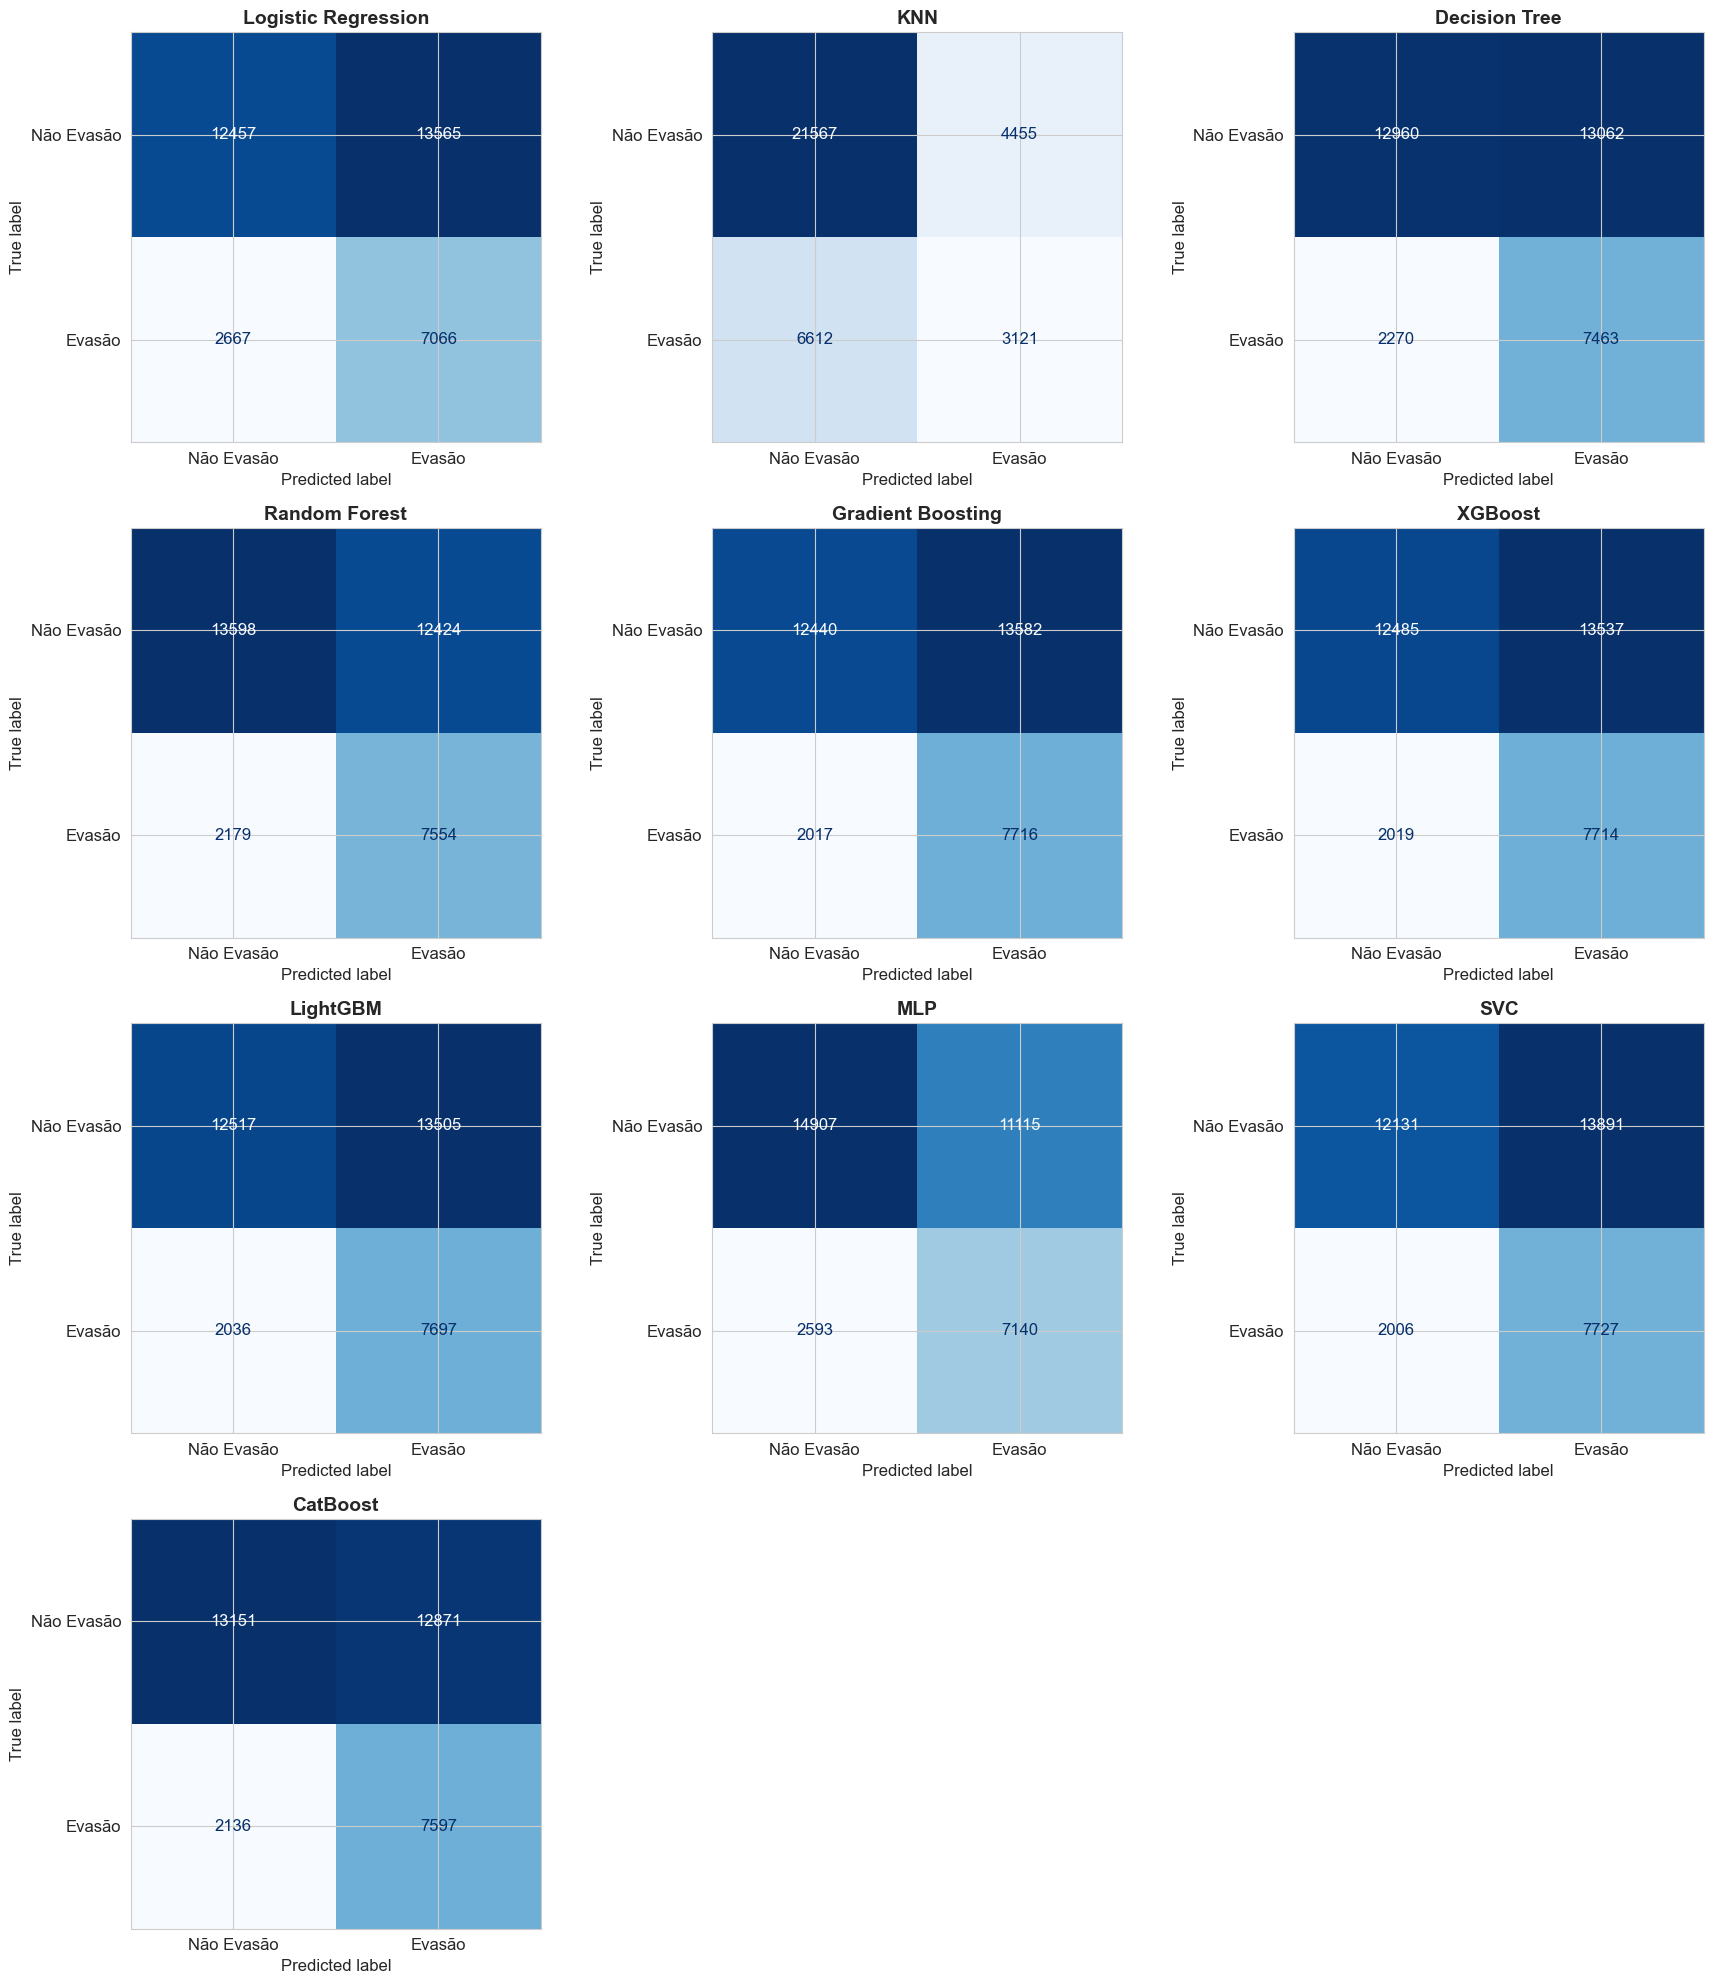

In [12]:
# =============================================================================
# 7. MATRIZES DE CONFUSÃO
# =============================================================================

print("\n" + "=" * 70)
print("7. MATRIZES DE CONFUSÃO")
print("=" * 70)

n_models = len(predictions)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Evasão', 'Evasão'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}', fontweight='bold')

# Remove eixos vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('figures/matrizes_confusao.png', dpi=300, bbox_inches='tight')
plt.show()



8. CURVAS ROC


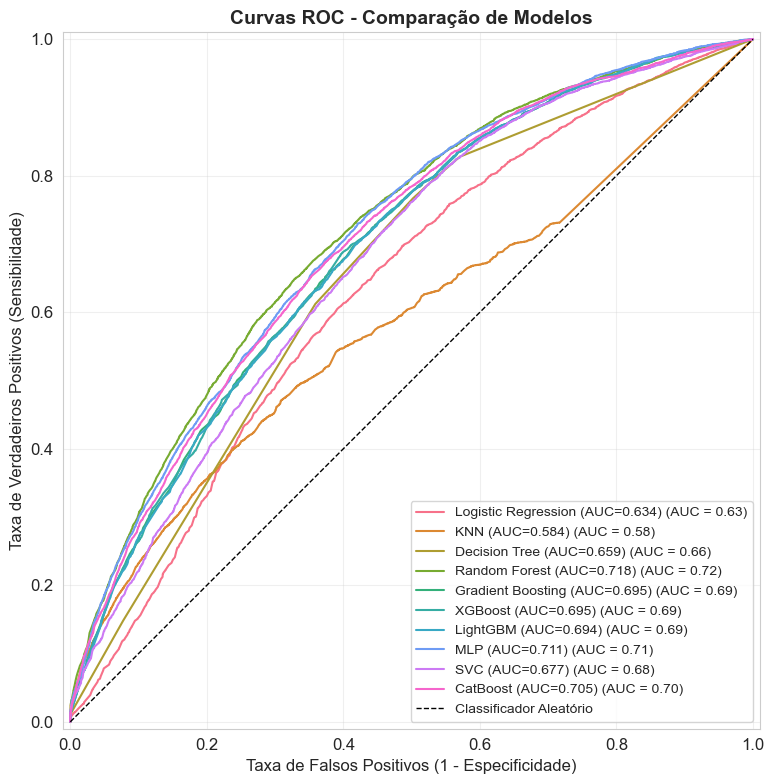

In [13]:
# =============================================================================
# 8. CURVAS ROC
# =============================================================================

print("\n" + "=" * 70)
print("8. CURVAS ROC")
print("=" * 70)

fig, ax = plt.subplots(figsize=(12, 8))

for i, (name, y_proba) in enumerate(probabilities.items()):
    if y_proba is not None:
        RocCurveDisplay.from_predictions(
            y_test, y_proba, name=f'{name} (AUC={df_test.loc[name, "AUC-ROC"]:.3f})',
            ax=ax, color=COLORS[i % len(COLORS)]
        )

# Adicionar linha de referência
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificador Aleatório')
ax.set_title('Curvas ROC - Comparação de Modelos', fontweight='bold')
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/curvas_roc.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
# =============================================================================
# 9. RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
# =============================================================================

print("\n" + "=" * 70)
print("9. RELATÓRIOS DE CLASSIFICAÇÃO DETALHADOS")
print("=" * 70)

for name in ['Random Forest', 'LightGBM', 'XGBoost']:
    if name in predictions:
        print(f"\n{'='*50}")
        print(f"Relatório: {name}")
        print(f"{'='*50}")
        print(classification_report(
            y_test, predictions[name],
            target_names=['Não Evasão', 'Evasão'],
            digits=4
        ))



9. RELATÓRIOS DE CLASSIFICAÇÃO DETALHADOS

Relatório: Random Forest
              precision    recall  f1-score   support

  Não Evasão     0.8619    0.5226    0.6506     26022
      Evasão     0.3781    0.7761    0.5085      9733

    accuracy                         0.5916     35755
   macro avg     0.6200    0.6493    0.5796     35755
weighted avg     0.7302    0.5916    0.6119     35755


Relatório: LightGBM
              precision    recall  f1-score   support

  Não Evasão     0.8601    0.4810    0.6170     26022
      Evasão     0.3630    0.7908    0.4976      9733

    accuracy                         0.5653     35755
   macro avg     0.6116    0.6359    0.5573     35755
weighted avg     0.7248    0.5653    0.5845     35755


Relatório: XGBoost
              precision    recall  f1-score   support

  Não Evasão     0.8608    0.4798    0.6161     26022
      Evasão     0.3630    0.7926    0.4979      9733

    accuracy                         0.5649     35755
   macro avg     0


10. INTERPRETABILIDADE DO MODELO COM SHAP

Modelo selecionado para interpretação: LightGBM


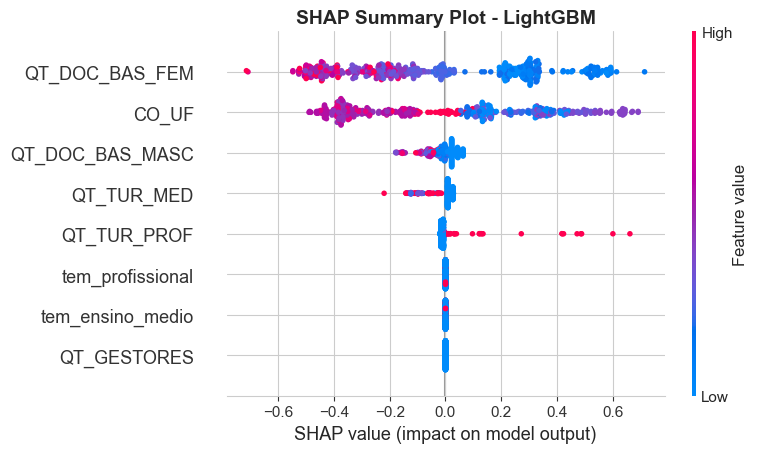

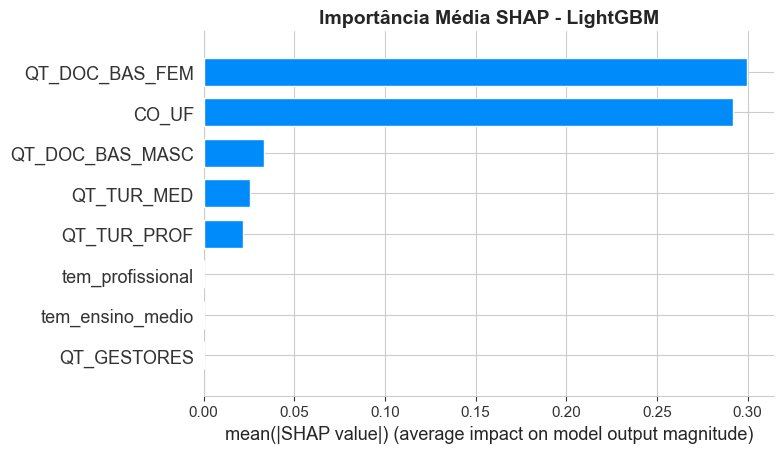

In [15]:
# =============================================================================
# 10. INTERPRETABILIDADE COM SHAP
# =============================================================================

print("\n" + "=" * 70)
print("10. INTERPRETABILIDADE DO MODELO COM SHAP")
print("=" * 70)

# Selecionar o melhor modelo baseado em árvore para interpretação
tree_models = ['LightGBM', 'XGBoost', 'Random Forest', 'Gradient Boosting']
interpretable_model_name = None

for name in tree_models:
    if name in best_models and name in predictions:
        interpretable_model_name = name
        break

if interpretable_model_name:
    print(f"\nModelo selecionado para interpretação: {interpretable_model_name}")
    
    model = best_models[interpretable_model_name]
    
    # Usar uma amostra para SHAP (para performance)
    X_sample = X_test_proc.sample(n=min(500, len(X_test_proc)), random_state=SEED)
    
    try:
        # Criar explainer
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        
        # Summary plot
        fig, ax = plt.subplots(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, show=False)
        plt.title(f'SHAP Summary Plot - {interpretable_model_name}', fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'figures/shap_summary_{interpretable_model_name}.png', 
                    dpi=300, bbox_inches='tight')
        plt.show()
        
        # Bar plot de importância média
        fig, ax = plt.subplots(figsize=(10, 6))
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
        plt.title(f'Importância Média SHAP - {interpretable_model_name}', fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'figures/shap_bar_{interpretable_model_name}.png', 
                    dpi=300, bbox_inches='tight')
        plt.show()
        
    except Exception as e:
        print(f"Erro ao gerar SHAP: {e}")
        print("Tentando método alternativo com KernelExplainer...")